# Sales & Demand Forecasting for Retail Businesses

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("data/superstore.csv", encoding="latin1")

print("Shape: ", df.shape)
df.info()
df.head()

Shape:  (9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/06/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [34]:
rows_before = len(df)

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")

print("Duplicates found :", df.duplicated().sum())
print("Missing values :")
print(df[["Order Date", "Sales"]].isna().sum())

df = df.drop_duplicates()
df = df.dropna(subset=["Order Date", "Sales"])
df = df[df["Sales"] > 0].copy()

print(f"\nRows before: {rows_before} | after: {len(df)} | removed: {rows_before - len(df)}")

Duplicates found : 0
Missing values :
Order Date    0
Sales         0
dtype: int64

Rows before: 9994 | after: 9994 | removed: 0


Months in data: 48


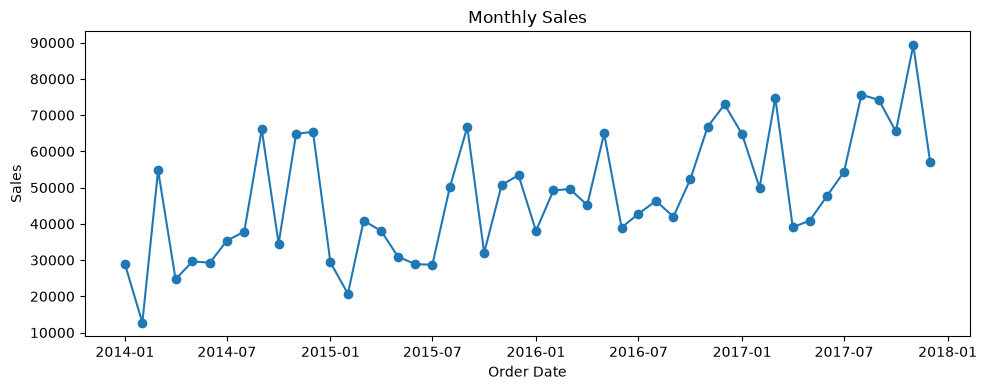

In [35]:
monthly = (
    df.set_index("Order Date")["Sales"]
      .resample("MS").sum()
      .to_frame("sales")
)

print("Months in data:", len(monthly))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["sales"], marker="o", color="#1f77b4")
ax.set_title("Monthly Sales")
ax.set_xlabel("Order Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

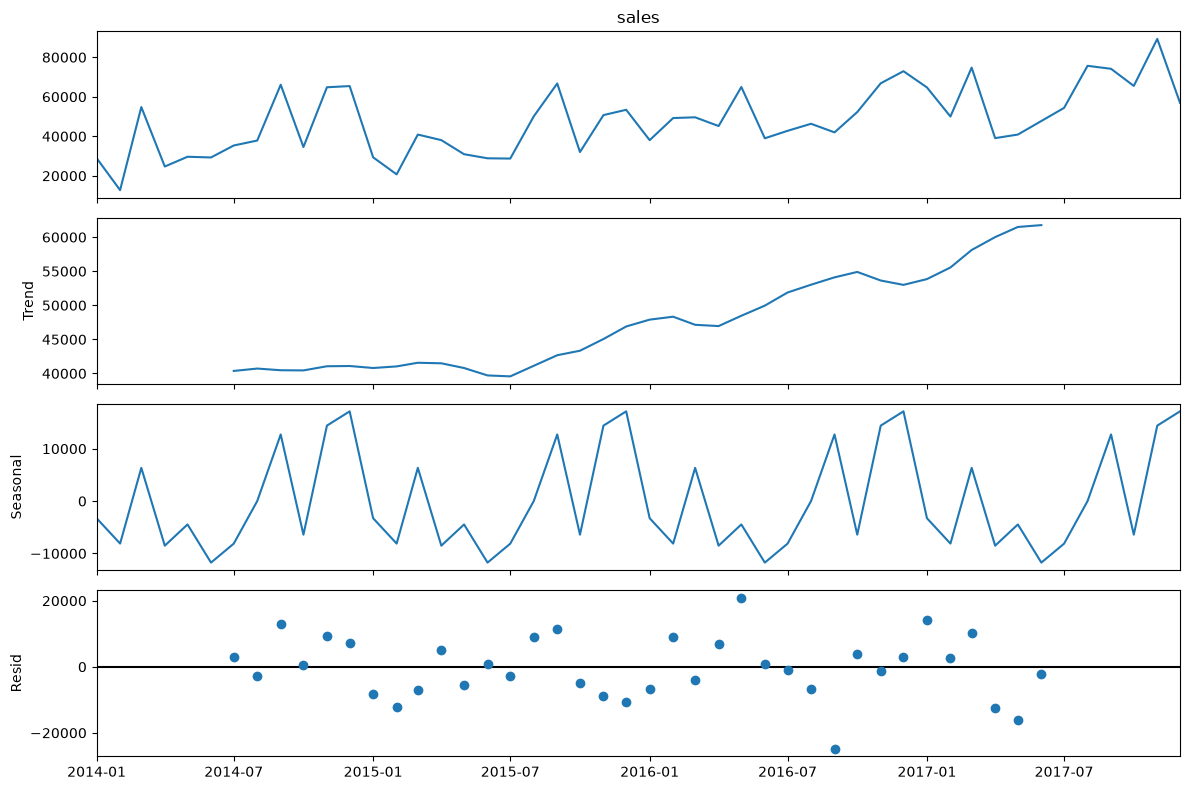

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

if len(monthly) >= 24:
    result = seasonal_decompose(monthly["sales"], model="additive", period=12)
    fig = result.plot()
    fig.set_size_inches(12, 8)
    plt.tight_layout()
    plt.show()
else:
    print("Decomposition ke liye kam se kam 24 months chahiye.")

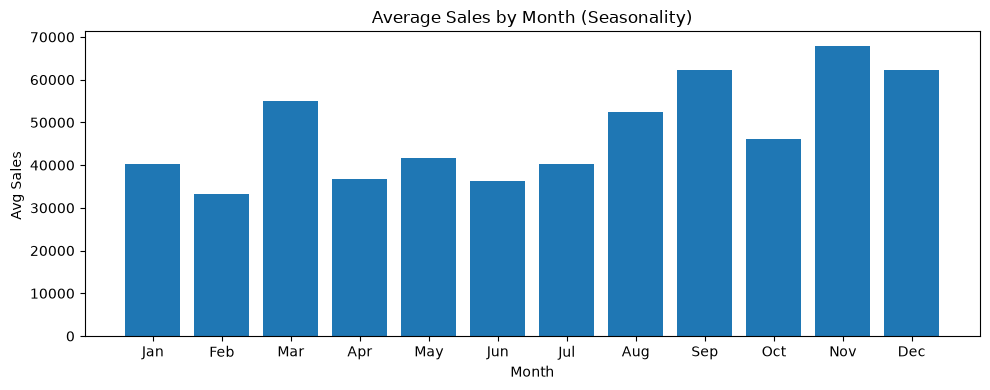

Strongest month: Nov
Weakest month  : Feb


In [37]:
avg_by_month = monthly["sales"].groupby(monthly.index.month).mean()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_names, avg_by_month.values, color="#1f77b4")
ax.set_title("Average Sales by Month (Seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Sales ")
plt.tight_layout()
plt.savefig("outputs/seasonality.png", dpi=200)
plt.show()

print("Strongest month:", month_names[avg_by_month.idxmax() - 1])
print("Weakest month  :", month_names[avg_by_month.idxmin() - 1])

In [38]:
def make_features(index, t_start=0):
   
    month_cat = pd.Categorical(index.month, categories=range(1, 13))
    X = pd.get_dummies(month_cat, prefix="m", drop_first=True).astype(int)
    X.index = index
    X["t"] = np.arange(t_start, t_start + len(index))
    return X

y = monthly["sales"]
X = make_features(monthly.index, t_start=0)

print("X shape:", X.shape, "| y shape:", y.shape)
X.head()

X shape: (48, 12) | y shape: (48,)


,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12,t
Order Date,,,,,,,,,,,,
2014-01-01,0,0,0,0,0,0,0,0,0,0,0,0
2014-02-01,1,0,0,0,0,0,0,0,0,0,0,1
2014-03-01,0,1,0,0,0,0,0,0,0,0,0,2
2014-04-01,0,0,1,0,0,0,0,0,0,0,0,3
2014-05-01,0,0,0,1,0,0,0,0,0,0,0,4


In [39]:
TEST_SIZE = 12
X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print("Train:", y_train.index.min().date(), "to", y_train.index.max().date(), f"({len(y_train)} months)")
print("Test :", y_test.index.min().date(),  "to", y_test.index.max().date(),  f"({len(y_test)} months)")

Train: 2014-01-01 to 2016-12-01 (36 months)
Test : 2017-01-01 to 2017-12-01 (12 months)


In [40]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

pred_naive = y_train.iloc[-12:].values


lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)


hw = ExponentialSmoothing(
    y_train, trend="add", seasonal="add", seasonal_periods=12
).fit()
pred_hw = hw.forecast(TEST_SIZE).values

preds = {
    "Seasonal Naive":    pred_naive,
    "Linear Regression": pred_lr,
    "Holt-Winters":      pred_hw,
}
print("Models trained:", list(preds))

Models trained: ['Seasonal Naive', 'Linear Regression', 'Holt-Winters']


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(name, actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE %": mape}

results = pd.DataFrame(
    [evaluate(name, y_test.values, p) for name, p in preds.items()]
).round(1).set_index("Model")

best_name = results["RMSE"].idxmin()   
best_pred = preds[best_name]
best_rmse = results.loc[best_name, "RMSE"]
best_mape = results.loc[best_name, "MAPE %"]

display(results)
print(f"Best model: {best_name}  (RMSE = {best_rmse:,.0f}, MAPE = {best_mape:.1f}%)")

,MAE,RMSE,MAPE %
Model,,,
Seasonal Naive,18032.0,20425.0,28.9
Linear Regression,13257.4,14398.7,21.7
Holt-Winters,15488.9,17642.4,24.9


Best model: Linear Regression  (RMSE = 14,399, MAPE = 21.7%)


In [42]:
errors = pd.DataFrame(
    {"actual": y_test.values, "pred": np.asarray(best_pred)},
    index=y_test.index,
)
errors["error"] = errors["actual"] - errors["pred"]
errors["pct_error"] = errors["error"] / errors["actual"] * 100

display(errors.round(1))

bias = errors["error"].mean()
print(f"Average error (bias): {bias:,.0f}  ->", "under-forecast" if bias > 0 else "over-forecast")
print("Worst month         :", errors["error"].abs().idxmax().strftime("%b %Y"))
print(f"MAPE                : {errors['pct_error'].abs().mean():.1f}%")

,actual,pred,error,pct_error
Order Date,,,,
2017-01-01,64734.3,42529.6,22204.7,34.3
2017-02-01,50011.5,37983.1,12028.4,24.1
2017-03-01,74774.1,58843.4,15930.7,21.3
2017-04-01,39072.0,46399.6,-7327.6,-18.8
2017-05-01,40882.4,52259.1,-11376.7,-27.8
2017-06-01,47742.3,42793.6,4948.8,10.4
2017-07-01,54382.1,46028.2,8353.9,15.4
2017-08-01,75675.3,55176.2,20499.1,27.1
2017-09-01,74164.6,68688.1,5476.5,7.4


Average error (bias): 7,244  -> under-forecast
Worst month         : Jan 2017
MAPE                : 21.7%


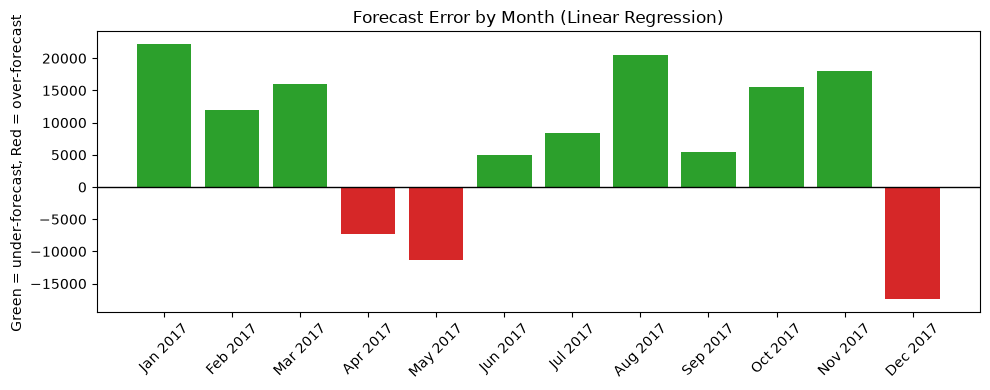

In [43]:
labels = errors.index.strftime("%b %Y")
colors = ["#2ca02c" if v > 0 else "#d62728" for v in errors["error"]]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, errors["error"], color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_title(f"Forecast Error by Month ({best_name})")
ax.set_ylabel("Green = under-forecast, Red = over-forecast ")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/error_by_month.png", dpi=200)
plt.show()

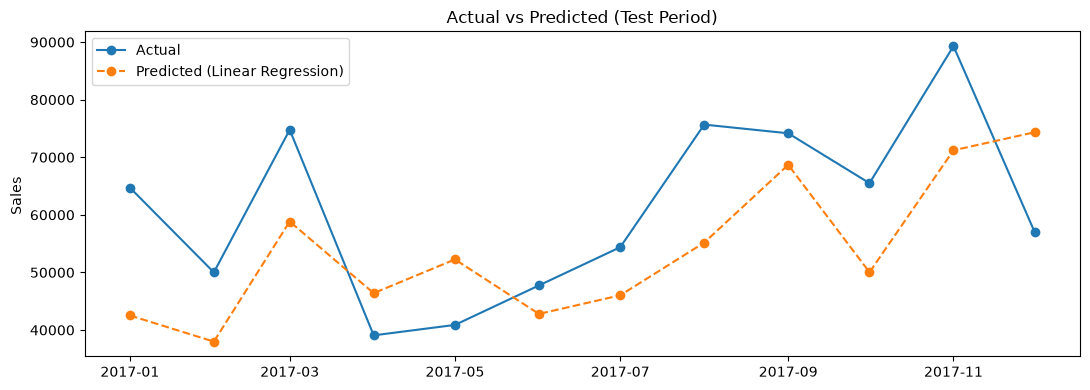

In [44]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y_test.index, y_test, label="Actual", color="#1f77b4", marker="o")
ax.plot(y_test.index, best_pred, label=f"Predicted ({best_name})",
        color="#ff7f0e", marker="o", ls="--")
ax.set_title("Actual vs Predicted (Test Period)")
ax.set_ylabel("Sales ")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/actual_vs_pred.png", dpi=200)
plt.show()

In [45]:
HORIZON = 12

future_index = pd.date_range(
    start=y.index[-1] + pd.offsets.MonthBegin(1),
    periods=HORIZON,
    freq="MS"
)

if best_name == "Holt-Winters":
    hw_full = ExponentialSmoothing(
        y, trend="add", seasonal="add", seasonal_periods=12
    ).fit()
    fc_values = hw_full.forecast(HORIZON).values

elif best_name == "Linear Regression":
    lr_full = LinearRegression().fit(X, y)
    X_future = make_features(future_index, t_start=len(y))
    fc_values = lr_full.predict(X_future)

else: 
    fc_values = np.resize(y.iloc[-12:].values, HORIZON)

forecast = pd.Series(np.clip(fc_values, 0, None), index=future_index, name="forecast")
lower = (forecast - 1.96 * best_rmse).clip(lower=0)
upper = forecast + 1.96 * best_rmse

forecast_df = pd.DataFrame({"forecast": forecast, "lower": lower, "upper": upper}).round(0)
forecast_df.index.name = "month"
forecast_df.to_csv("outputs/forecast.csv")

print("Forecast model:", best_name)
forecast_df

Forecast model: Linear Regression


,forecast,lower,upper
month,,,
2018-01-01,58720.0,30499.0,86942.0
2018-02-01,51630.0,23408.0,79851.0
2018-03-01,73466.0,45244.0,101687.0
2018-04-01,55207.0,26986.0,83429.0
2018-05-01,60055.0,31833.0,88276.0
2018-06-01,54670.0,26449.0,82892.0
2018-07-01,58756.0,30535.0,86978.0
2018-08-01,70941.0,42719.0,99162.0
2018-09-01,80697.0,52475.0,108918.0


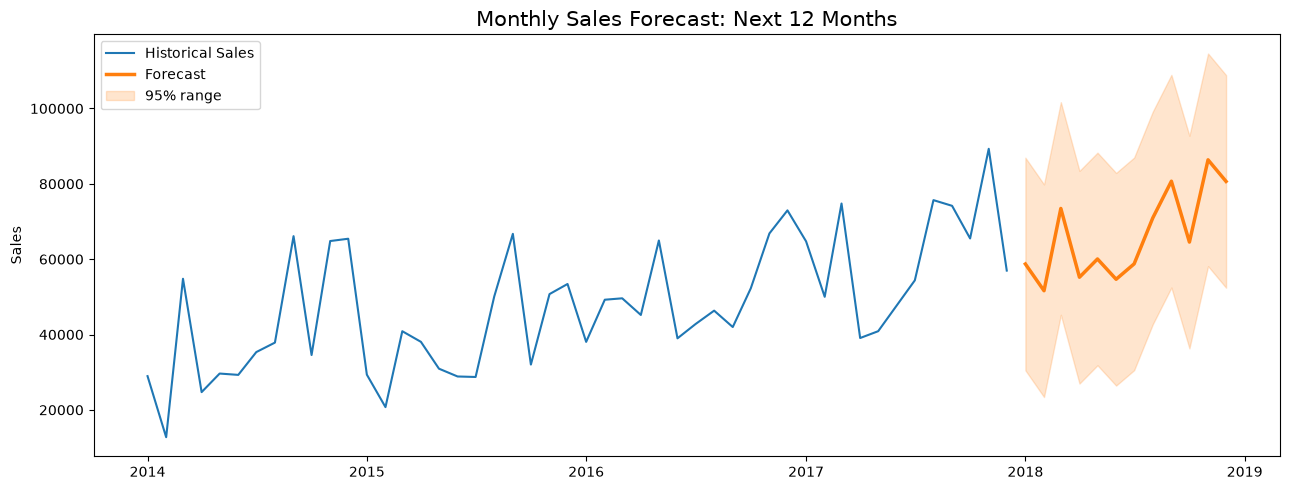

In [46]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y.index, y, label="Historical Sales", color="#1f77b4")
ax.plot(forecast.index, forecast, label="Forecast", color="#ff7f0e", lw=2.5)
ax.fill_between(forecast.index, lower, upper, color="#ff7f0e", alpha=0.2, label="95% range")
ax.set_title("Monthly Sales Forecast: Next 12 Months", fontsize=15)
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/forecast.png", dpi=200)
plt.show()

In [47]:
last_12 = y.iloc[-12:].sum()
next_12 = forecast.sum()
growth = (next_12 / last_12 - 1) * 100

peak_month = forecast.idxmax().strftime("%B %Y")
low_month  = forecast.idxmin().strftime("%B %Y")
top3 = forecast.nlargest(3).index.strftime("%b").tolist()

print("=" * 60)
print("SALES FORECASTING")
print("=" * 60)
print(f"Model used            : {best_name}")
print(f"Typical error (MAPE)  : about {best_mape:.1f}%")
print(f"Last 12 months sales  : ${last_12:,.0f}")
print(f"Next 12 months forecast: ${next_12:,.0f}  ({growth:+.1f}% vs last 12 months)")
print(f"Strongest month       : {peak_month}  (${forecast.max():,.0f})")
print(f"Weakest month         : {low_month}  (${forecast.min():,.0f})")
print(f"Top 3 months          : {', '.join(top3)}")
print()
print("HOW TO USE THIS FORECAST")
print(f"- Inventory : stock up 6-8 weeks before {', '.join(top3)}; avoid overbuying before {forecast.idxmin().strftime('%b')}.")
print("- Staffing  : plan extra hiring/shifts for the top 3 months.")
print(f"- Cash flow : keep a cash buffer for {forecast.idxmin().strftime('%b')} and for pre-peak stock purchases.")
print("- Marketing : run promotions in weak months to smooth demand.")
print("- Planning  : use the lower bound for a safe budget, the upper bound for a stretch target.")
print()
print("LIMITATIONS")
print("- Only a few years of history; promotions, holidays and pricing are not modeled.")
print("- Forecast is valid only if business conditions stay similar to the past.")

SALES FORECASTING
Model used            : Linear Regression
Typical error (MAPE)  : about 21.7%
Last 12 months sales  : $733,215
Next 12 months forecast: $795,694  (+8.5% vs last 12 months)
Strongest month       : November 2018  ($86,373)
Weakest month         : February 2018  ($51,630)
Top 3 months          : Nov, Sep, Dec

HOW TO USE THIS FORECAST
- Inventory : stock up 6-8 weeks before Nov, Sep, Dec; avoid overbuying before Feb.
- Staffing  : plan extra hiring/shifts for the top 3 months.
- Cash flow : keep a cash buffer for Feb and for pre-peak stock purchases.
- Marketing : run promotions in weak months to smooth demand.
- Planning  : use the lower bound for a safe budget, the upper bound for a stretch target.

LIMITATIONS
- Only a few years of history; promotions, holidays and pricing are not modeled.
- Forecast is valid only if business conditions stay similar to the past.
